# TFT Set 17 — Exploratory Data Analysis
Loads `data/tft_clean.csv` produced by `01_build_data.ipynb`.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("data/tft_clean.csv")
df["date"]  = pd.to_datetime(df["date"])
df["is_me"] = df["is_me"].astype(bool)

me    = df[df["is_me"]]
chall = df[~df["is_me"]]

print(f"{len(df):,} rows  |  {df['is_me'].sum()} my games  |  {(~df['is_me']).sum()} challenger games")
print(f"Columns: {len(df.columns)}")
df.head()

Matplotlib is building the font cache; this may take a moment.


1,273 rows  |  44 my games  |  1229 challenger games
Columns: 84


,match_id,date,player_name,is_me,placement,level,last_round,stage_round,gold_left,damage_to_players,...,trait_Stargazer_Medallion,trait_Stargazer_Mountain,trait_Stargazer_Serpent,trait_Stargazer_Shield,trait_Stargazer_Wolf,trait_SummonTrait,trait_TahmKenchUniqueTrait,trait_Timebreaker,trait_VexUniqueTrait,trait_ZedUniqueTrait
0,NA1_5562880650,2026-05-18 04:53:11.410,me,True,4,9,34,6-5,0,105,...,0,0,0,0,0,0,3,0,0,0
1,NA1_5560691122,2026-05-15 05:37:09.012,me,True,6,9,31,6-2,7,110,...,0,0,0,0,0,1,0,0,0,0
2,NA1_5559979852,2026-05-14 05:08:10.272,me,True,4,9,35,7-1,1,143,...,0,0,0,0,0,0,3,0,0,0
3,NA1_5559669327,2026-05-13 23:18:42.862,me,True,5,9,31,6-2,1,94,...,0,0,0,0,0,1,0,0,3,0
4,NA1_5559167035,2026-05-13 03:01:23.733,me,True,5,8,31,6-2,19,83,...,0,0,0,0,0,1,0,0,0,0


## 1. Sanity check — placement distribution

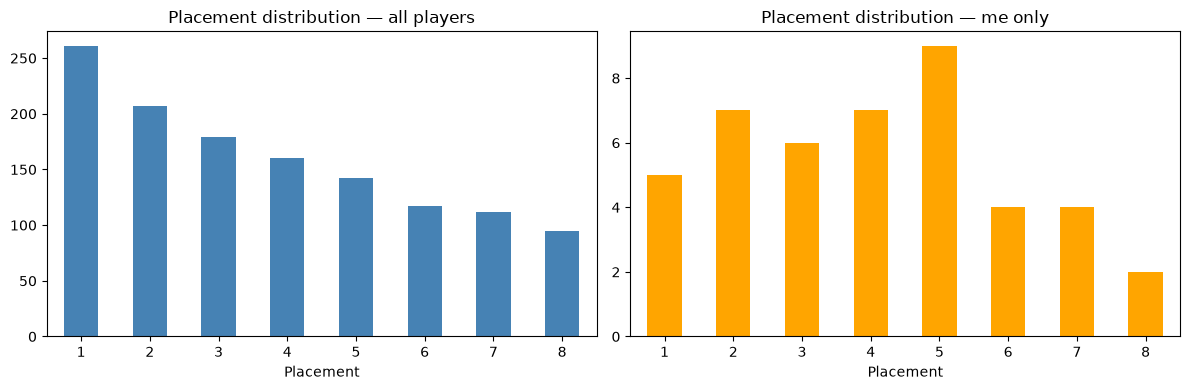

Top-4 rate overall: 63.4%
Top-4 rate (me):    56.8%
Top-4 rate (chall): 63.6%


In [3]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

df["placement"].value_counts().sort_index().plot(kind="bar", ax=axes[0], color="steelblue")
axes[0].set_title("Placement distribution — all players")
axes[0].set_xlabel("Placement")
axes[0].tick_params(axis="x", rotation=0)

me["placement"].value_counts().sort_index().plot(kind="bar", ax=axes[1], color="orange")
axes[1].set_title("Placement distribution — me only")
axes[1].set_xlabel("Placement")
axes[1].tick_params(axis="x", rotation=0)

plt.tight_layout()
plt.show()

print(f"Top-4 rate overall: {df['top4'].mean():.1%}")
print(f"Top-4 rate (me):    {me['top4'].mean():.1%}")
print(f"Top-4 rate (chall): {chall['top4'].mean():.1%}")

## 2. Bivariate — mean feature value by placement
The headline plot: which features actually carry signal.

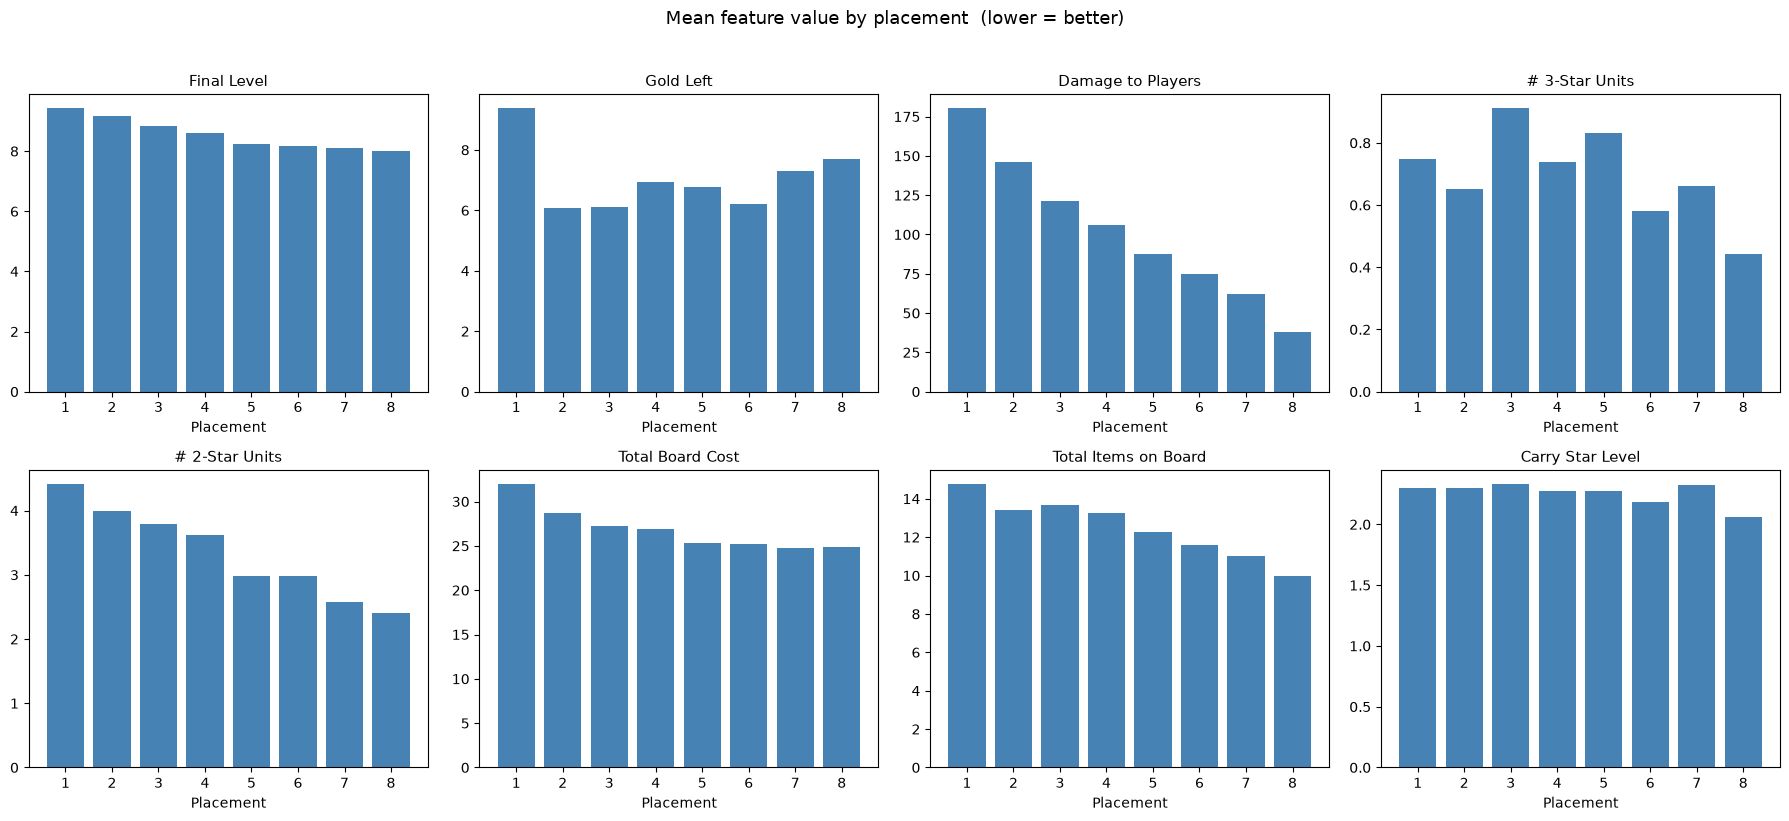

In [4]:
numeric_features = [
    ("level",             "Final Level"),
    ("gold_left",         "Gold Left"),
    ("damage_to_players", "Damage to Players"),
    ("n_3stars",          "# 3-Star Units"),
    ("n_2stars",          "# 2-Star Units"),
    ("total_board_cost",  "Total Board Cost"),
    ("total_items",       "Total Items on Board"),
    ("carry_tier",        "Carry Star Level"),
]

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()

for ax, (feat, label) in zip(axes, numeric_features):
    means = df.groupby("placement")[feat].mean()
    ax.bar(means.index, means.values, color="steelblue")
    ax.set_title(label, fontsize=11)
    ax.set_xlabel("Placement")
    ax.set_xticks(range(1, 9))
    ax.tick_params(axis="x", rotation=0)

plt.suptitle("Mean feature value by placement  (lower = better)", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

## 3. Me vs Challenger — distribution overlays

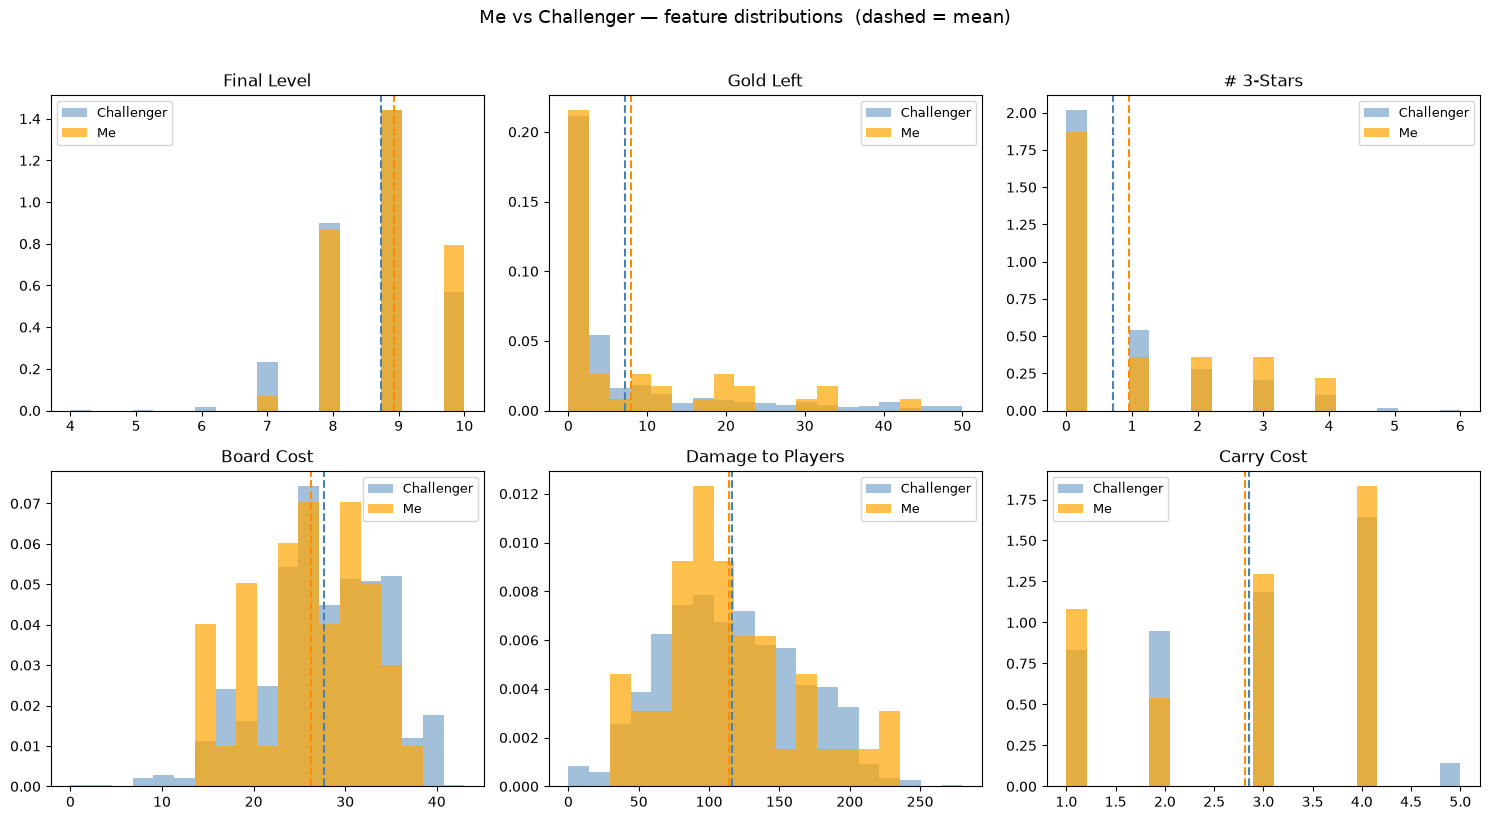

,me_mean,chall_mean,diff
level,8.93,8.72,0.21
gold_left,7.98,7.16,0.82
n_3stars,0.95,0.71,0.24
total_board_cost,26.30,27.65,-1.35
damage_to_players,114.00,116.04,-2.04
carry_cost,2.82,2.86,-0.04


In [5]:
overlay_features = [
    ("level",             "Final Level"),
    ("gold_left",         "Gold Left"),
    ("n_3stars",          "# 3-Stars"),
    ("total_board_cost",  "Board Cost"),
    ("damage_to_players", "Damage to Players"),
    ("carry_cost",        "Carry Cost"),
]

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for ax, (feat, label) in zip(axes, overlay_features):
    bins = np.linspace(df[feat].dropna().min(), df[feat].dropna().max(), 20)
    ax.hist(chall[feat].dropna(), bins=bins, density=True,
            alpha=0.5, color="steelblue", label="Challenger")
    ax.hist(me[feat].dropna(), bins=bins, density=True,
            alpha=0.7, color="orange", label="Me")
    ax.axvline(chall[feat].mean(), color="steelblue",  linestyle="--", linewidth=1.5)
    ax.axvline(me[feat].mean(),    color="darkorange", linestyle="--", linewidth=1.5)
    ax.set_title(label)
    ax.legend(fontsize=9)

plt.suptitle("Me vs Challenger — feature distributions  (dashed = mean)", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

summary = pd.DataFrame({
    "me_mean":    me[  [f for f, _ in overlay_features]].mean(),
    "chall_mean": chall[[f for f, _ in overlay_features]].mean(),
}).round(2)
summary["diff"] = (summary["me_mean"] - summary["chall_mean"]).round(2)
summary

## 4. Carry analysis

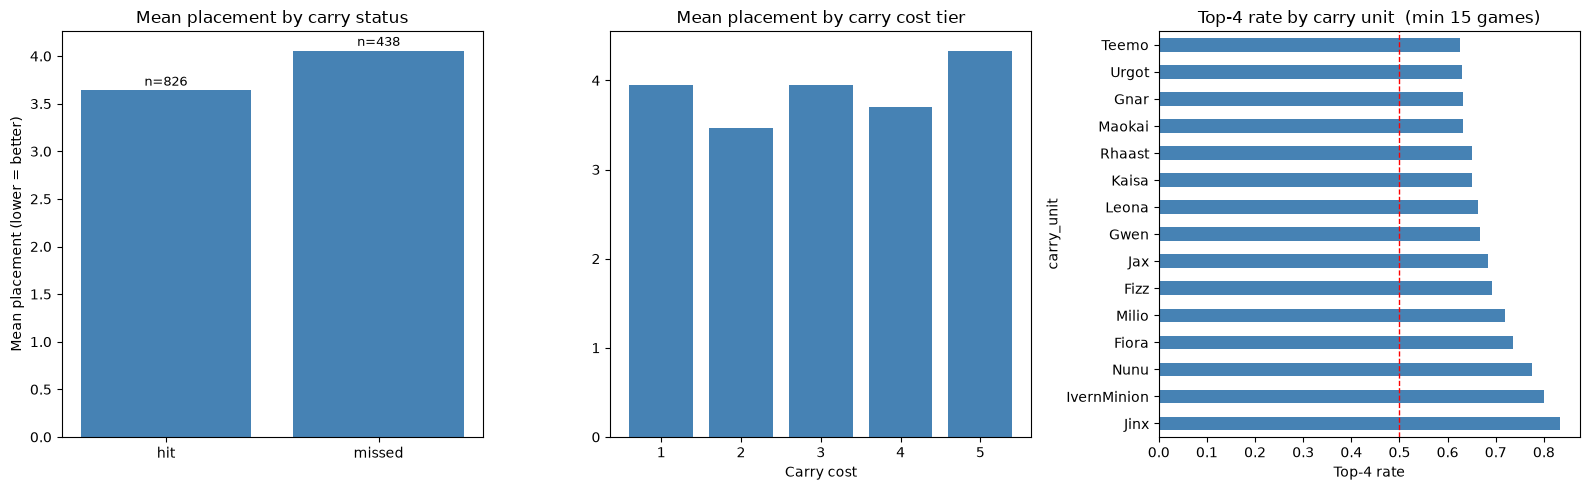

,top4_rate,games
carry_unit,,
Jinx,0.833333,18
IvernMinion,0.800000,15
Nunu,0.774436,133
Fiora,0.736842,19
Milio,0.720000,75
Fizz,0.692308,26
Jax,0.682927,41
Gwen,0.666667,15
Leona,0.662791,86


In [6]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# carry status vs mean placement
cs = (df.groupby("carry_status")["placement"]
        .agg(["mean", "count"]).reset_index()
        .query("count >= 10").sort_values("mean"))
axes[0].bar(cs["carry_status"], cs["mean"], color="steelblue")
axes[0].set_title("Mean placement by carry status")
axes[0].set_ylabel("Mean placement (lower = better)")
for bar, cnt in zip(axes[0].patches, cs["count"]):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
                 f"n={cnt}", ha="center", fontsize=9)

# carry cost vs mean placement
cc = (df.dropna(subset=["carry_cost"])
        .groupby("carry_cost")["placement"]
        .agg(["mean", "count"]).reset_index())
axes[1].bar(cc["carry_cost"].astype(int), cc["mean"], color="steelblue")
axes[1].set_title("Mean placement by carry cost tier")
axes[1].set_xlabel("Carry cost")
axes[1].set_xticks([1, 2, 3, 4, 5])

# top-4 rate by carry unit (min 15 games)
carry_top4 = (df.groupby("carry_unit")
                .agg(top4_rate=("top4", "mean"), games=("top4", "count"))
                .query("games >= 15")
                .sort_values("top4_rate", ascending=False)
                .head(15))
carry_top4["top4_rate"].plot(kind="barh", ax=axes[2], color="steelblue")
axes[2].set_title("Top-4 rate by carry unit  (min 15 games)")
axes[2].set_xlabel("Top-4 rate")
axes[2].axvline(0.5, color="red", linestyle="--", linewidth=1)

plt.tight_layout()
plt.show()
carry_top4

## 6. Trait analysis

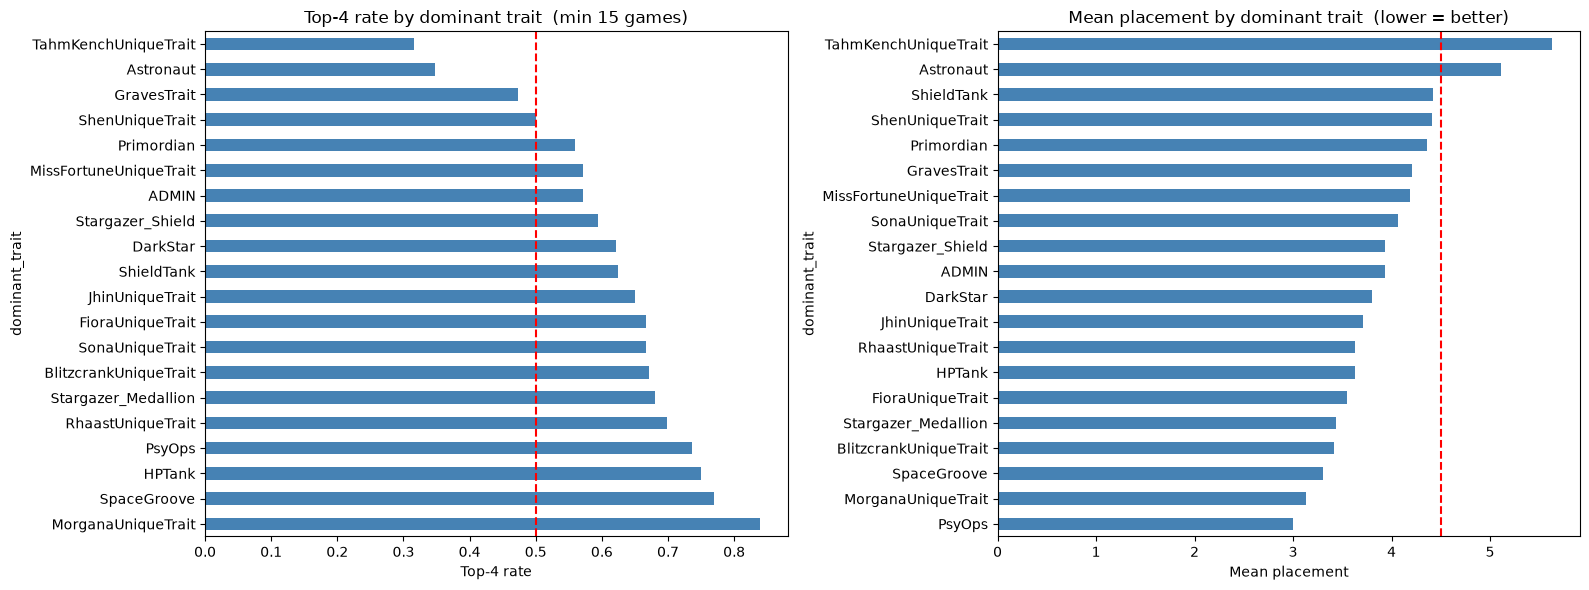

,mean_placement,top4_rate,count
dominant_trait,,,
MorganaUniqueTrait,3.129032,0.838710,31
SpaceGroove,3.307692,0.769231,52
HPTank,3.625000,0.750000,16
PsyOps,3.000000,0.736842,19
RhaastUniqueTrait,3.625899,0.697842,139
Stargazer_Medallion,3.440000,0.680000,25
BlitzcrankUniqueTrait,3.414110,0.671779,326
SonaUniqueTrait,4.066667,0.666667,15
FioraUniqueTrait,3.548387,0.666667,93


In [8]:
trait_stats = (df.groupby("dominant_trait")
               .agg(mean_placement=("placement", "mean"),
                    top4_rate=("top4", "mean"),
                    count=("placement", "count"))
               .query("count >= 15")
               .sort_values("top4_rate", ascending=False))

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

trait_stats["top4_rate"].plot(kind="barh", ax=axes[0], color="steelblue")
axes[0].set_title("Top-4 rate by dominant trait  (min 15 games)")
axes[0].set_xlabel("Top-4 rate")
axes[0].axvline(0.5, color="red", linestyle="--")

trait_stats["mean_placement"].sort_values().plot(kind="barh", ax=axes[1], color="steelblue")
axes[1].set_title("Mean placement by dominant trait  (lower = better)")
axes[1].set_xlabel("Mean placement")
axes[1].axvline(4.5, color="red", linestyle="--")

plt.tight_layout()
plt.show()
trait_stats